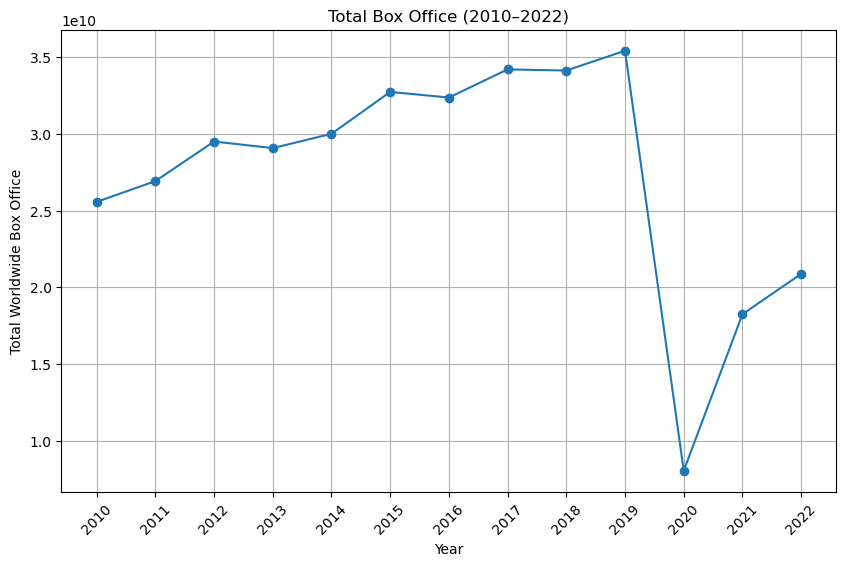

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Dosyaları oku
df1 = pd.read_csv("2000-2009 Movies Box Ofice Collection.csv")
df2 = pd.read_csv("2010-2024 Movies Box Ofice Collection.csv")
df3 = pd.read_csv("2024 Movies Box Ofice Collection.csv")

# Birleştir
df = pd.concat([df1, df2, df3], ignore_index=True)

# Kolon temizleme
df.columns = df.columns.str.strip()

# Year ve gelir kolonlarını otomatik bul
year_col = [c for c in df.columns if "year" in c.lower()][0]
money_col = [c for c in df.columns if "world" in c.lower() or "gross" in c.lower() or "box" in c.lower()][0]

# Gelir kolonunu temizle
df[money_col] = df[money_col].astype(str).str.replace(r"[^\d.]", "", regex=True)
df[money_col] = pd.to_numeric(df[money_col], errors="coerce")

# Year'ı sayıya çevir
df[year_col] = pd.to_numeric(df[year_col], errors="coerce")

# Yıllara göre toplam
yearly = df.groupby(year_col)[money_col].sum().sort_index()

# 🎯 2010–2022 arası filtre
filtered = yearly[(yearly.index >= 2010) & (yearly.index <= 2022)]

# Grafik
plt.figure(figsize=(10,6))
plt.plot(filtered.index, filtered.values, marker='o')

plt.xlabel("Year")
plt.ylabel("Total Worldwide Box Office")
plt.title("Total Box Office (2010–2022)")

plt.grid(True)
plt.xticks(filtered.index, rotation=45)

plt.show()

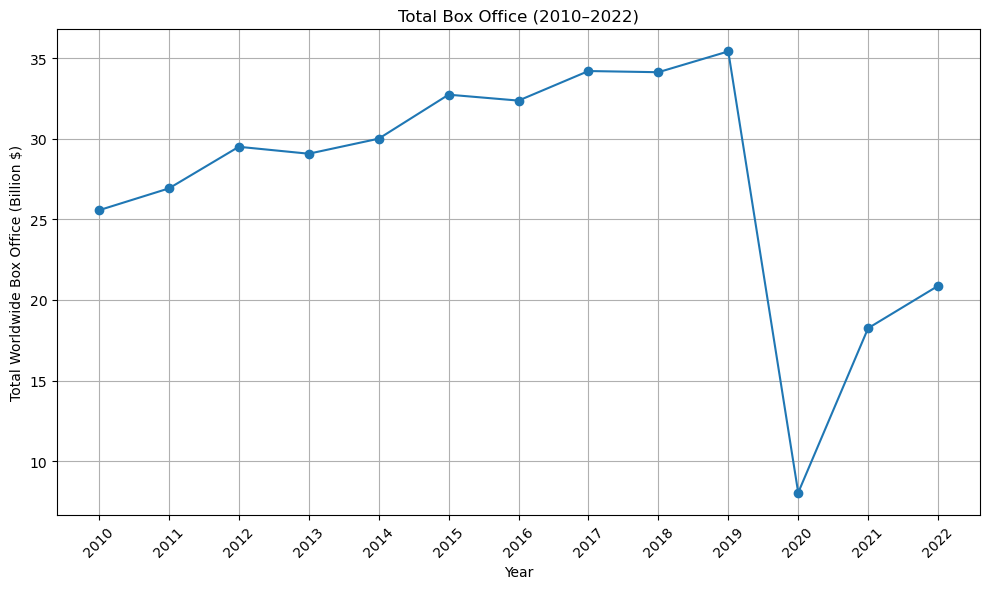

In [8]:
import matplotlib.pyplot as plt

# Milyara çevir
filtered_billion = filtered / 1e9

plt.figure(figsize=(10,6))
plt.plot(filtered_billion.index, filtered_billion.values, marker='o')

plt.xlabel("Year")
plt.ylabel("Total Worldwide Box Office (Billion $)")
plt.title("Total Box Office (2010–2022)")

plt.grid(True)
plt.xticks(filtered_billion.index, rotation=45)

plt.tight_layout()
plt.savefig("box_office_2010_2022.png", dpi=300)
plt.show()

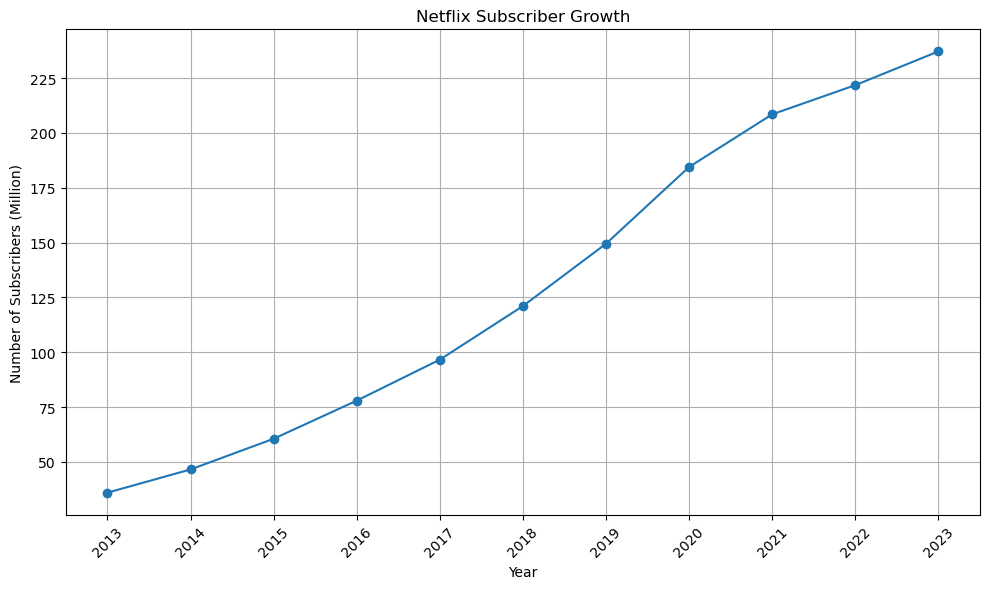

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Dosyayı oku
df = pd.read_csv("Netflix_Customer _Subscription.csv")

# 2️⃣ Kolon isimlerini temizle
df.columns = df.columns.str.strip()

# 3️⃣ Kolonları belirle
time_col = "Time Period"
sub_col = "Subscribers"

# 4️⃣ Subscriber kolonunu sayıya çevir
df[sub_col] = df[sub_col].astype(str).str.replace(r"[^\d.]", "", regex=True)
df[sub_col] = pd.to_numeric(df[sub_col], errors="coerce")

# 5️⃣ Time Period'tan yılı çıkar (eğer format 2010-Q1 gibi ise)
df["Year"] = df[time_col].astype(str).str.extract(r"(\d{4})")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# 6️⃣ Yıllık ortalama al
yearly = df.groupby("Year")[sub_col].mean().sort_index()

# 7️⃣ Eğer veri zaten milyon ise bu satırı sil
yearly_million = yearly / 1e6

# 8️⃣ Grafik
plt.figure(figsize=(10,6))
plt.plot(yearly_million.index, yearly_million.values, marker='o')

plt.xlabel("Year")
plt.ylabel("Number of Subscribers (Million)")
plt.title("Netflix Subscriber Growth")

plt.grid(True)
plt.xticks(yearly_million.index, rotation=45)

plt.tight_layout()
plt.savefig("netflix_subscribers_2013_2023.png", dpi=300)
plt.show()

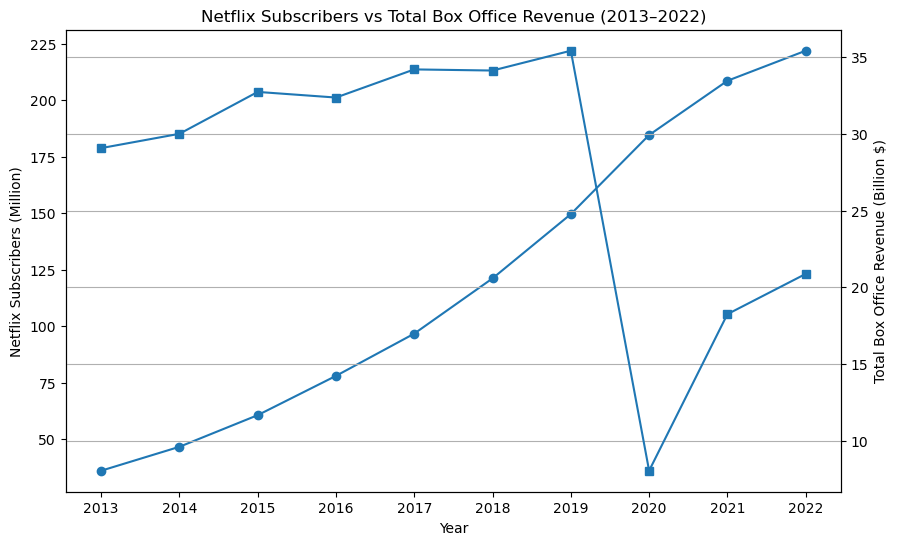

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 1️⃣ BOX OFFICE VERİSİ
# -------------------------

df1 = pd.read_csv("2000-2009 Movies Box Ofice Collection.csv")
df2 = pd.read_csv("2010-2024 Movies Box Ofice Collection.csv")
df3 = pd.read_csv("2024 Movies Box Ofice Collection.csv")

box_df = pd.concat([df1, df2, df3], ignore_index=True)
box_df.columns = box_df.columns.str.strip()

year_col = [c for c in box_df.columns if "year" in c.lower()][0]
money_col = [c for c in box_df.columns if "world" in c.lower() or "gross" in c.lower() or "box" in c.lower()][0]

box_df[money_col] = box_df[money_col].astype(str).str.replace(r"[^\d.]", "", regex=True)
box_df[money_col] = pd.to_numeric(box_df[money_col], errors="coerce")
box_df[year_col] = pd.to_numeric(box_df[year_col], errors="coerce")

box_yearly = box_df.groupby(year_col)[money_col].sum().sort_index()
box_yearly = box_yearly[(box_yearly.index >= 2013) & (box_yearly.index <= 2022)]
box_yearly_billion = box_yearly / 1e9


# -------------------------
# 2️⃣ NETFLIX VERİSİ
# -------------------------

netflix_df = pd.read_csv("Netflix_Customer _Subscription.csv")
netflix_df.columns = netflix_df.columns.str.strip()

netflix_df["Subscribers"] = netflix_df["Subscribers"].astype(str).str.replace(r"[^\d.]", "", regex=True)
netflix_df["Subscribers"] = pd.to_numeric(netflix_df["Subscribers"], errors="coerce")

netflix_df["Year"] = netflix_df["Time Period"].astype(str).str.extract(r"(\d{4})")
netflix_df["Year"] = pd.to_numeric(netflix_df["Year"], errors="coerce")

netflix_yearly = netflix_df.groupby("Year")["Subscribers"].mean().sort_index()
netflix_yearly = netflix_yearly[(netflix_yearly.index >= 2013) & (netflix_yearly.index <= 2022)]
netflix_yearly_million = netflix_yearly / 1e6


# -------------------------
# 3️⃣ ÇİFT EKSENLİ GRAFİK
# -------------------------

fig, ax1 = plt.subplots(figsize=(10,6))

# Netflix çizgisi (sol eksen)
ax1.plot(netflix_yearly_million.index, netflix_yearly_million.values, marker='o')
ax1.set_xlabel("Year")
ax1.set_ylabel("Netflix Subscribers (Million)")
ax1.tick_params(axis='y')

# Box Office çizgisi (sağ eksen)
ax2 = ax1.twinx()
ax2.plot(box_yearly_billion.index, box_yearly_billion.values, marker='s')
ax2.set_ylabel("Total Box Office Revenue (Billion $)")
ax2.tick_params(axis='y')

plt.title("Netflix Subscribers vs Total Box Office Revenue (2013–2022)")
plt.xticks(netflix_yearly_million.index, rotation=45)

plt.grid(True)
plt.show()

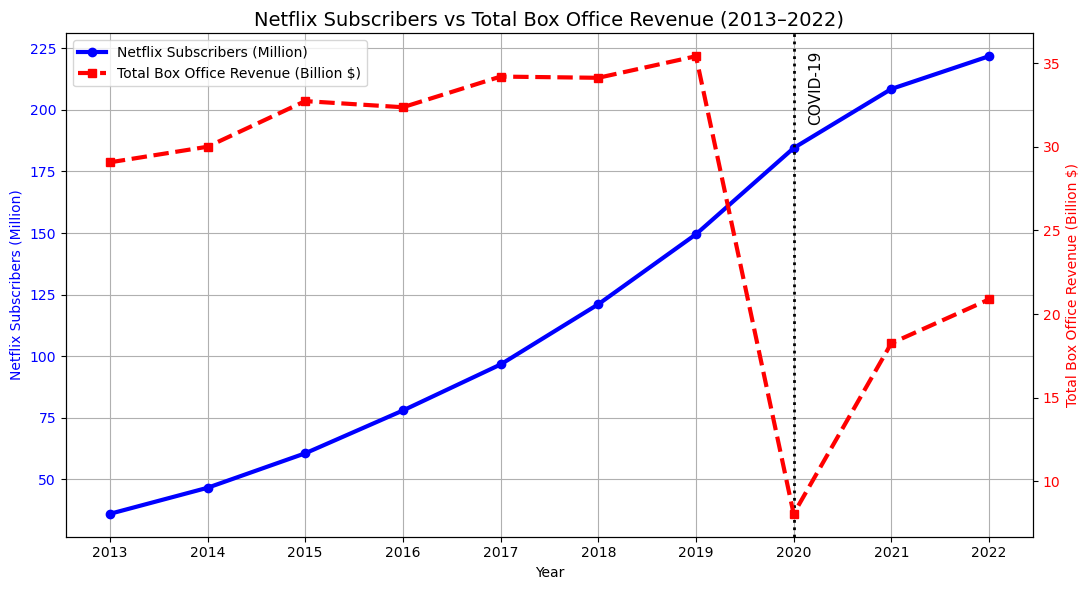

In [18]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(11,6))

# 🔵 Netflix (sol eksen)
line1 = ax1.plot(
    netflix_million.index,
    netflix_million.values,
    color="blue",
    marker="o",
    linewidth=3,
    label="Netflix Subscribers (Million)"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Netflix Subscribers (Million)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# 🔴 Box Office (sağ eksen)
ax2 = ax1.twinx()
line2 = ax2.plot(
    box_billion.index,
    box_billion.values,
    color="red",
    linestyle="--",
    marker="s",
    linewidth=3,
    label="Total Box Office Revenue (Billion $)"
)

ax2.set_ylabel("Total Box Office Revenue (Billion $)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# 🦠 COVID dikey çizgi
ax1.axvline(2020, color="black", linestyle=":", linewidth=2)

# 🦠 COVID yazısı (üstte ve çizginin sağında)
y_min, y_max = ax1.get_ylim()
ax1.text(
    2020.15,
    y_max * 0.97,
    "COVID-19",
    rotation=90,
    va="top",
    ha="left",
    fontsize=11,
    color="black"
)

# Başlık ve grid
plt.title("Netflix Subscribers vs Total Box Office Revenue (2013–2022)", fontsize=14)
plt.xticks(netflix_million.index, rotation=45)
ax1.grid(True)

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

# Word için kaydet
plt.tight_layout()
plt.savefig("netflix_vs_boxoffice_final.png", dpi=300, bbox_inches="tight")

plt.show()